In [13]:
%load_ext autoreload 
%autoreload 2

import os
import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\2
RTB2004_CHAN1.CSV → phase = 51.28725923128306
RTB2004_CHAN1(1).CSV → phase = 48.944647837861545
RTB2004_CHAN1(2).CSV → phase = 46.86059636586778
RTB2004_CHAN1(3).CSV → phase = 45.37616855591583
RTB2004_CHAN1(4).CSV → phase = 45.71143605035041
RTB2004_CHAN1(5).CSV → phase = 40.50479579545136
RTB2004_CHAN1(6).CSV → phase = 35.52138760674708


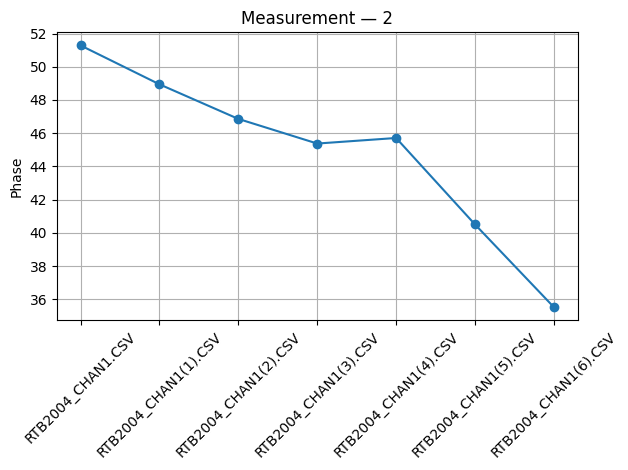


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\3
RTB2004_CHAN1.CSV → phase = 50.96585681595923
RTB2004_CHAN1(1).CSV → phase = 48.11873088064664
RTB2004_CHAN1(2).CSV → phase = 43.451534268282565
RTB2004_CHAN1(3).CSV → phase = 40.58887625290575
RTB2004_CHAN1(4).CSV → phase = 36.669172888321995
RTB2004_CHAN1(5).CSV → phase = 44.64475664963816
RTB2004_CHAN1(6).CSV → phase = 45.393444198204385
RTB2004_CHAN1(7).CSV → phase = 45.80406765831154


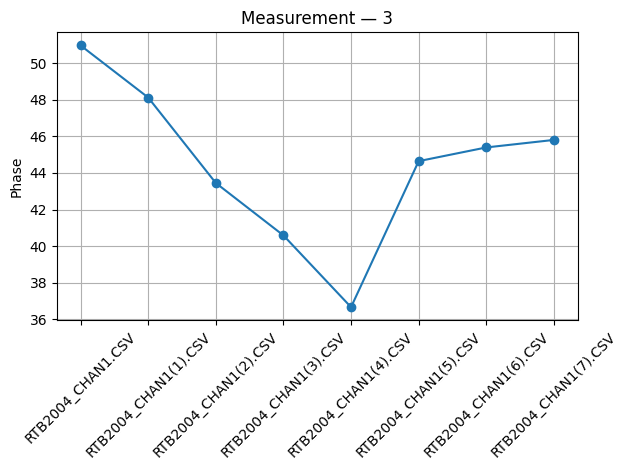


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\4
RTB2004_CHAN1.CSV → phase = 46.93163991593889
RTB2004_CHAN1(1).CSV → phase = 45.410029228282085
RTB2004_CHAN1(2).CSV → phase = 43.385193055556556
RTB2004_CHAN1(3).CSV → phase = 35.89999595756383
RTB2004_CHAN1(4).CSV → phase = 34.7734416407465
RTB2004_CHAN1(5).CSV → phase = 33.57098307501737
RTB2004_CHAN1(6).CSV → phase = 32.67540468397299
RTB2004_CHAN1(7).CSV → phase = 33.64236641002878
RTB2004_CHAN1(8).CSV → phase = 33.599053910121214


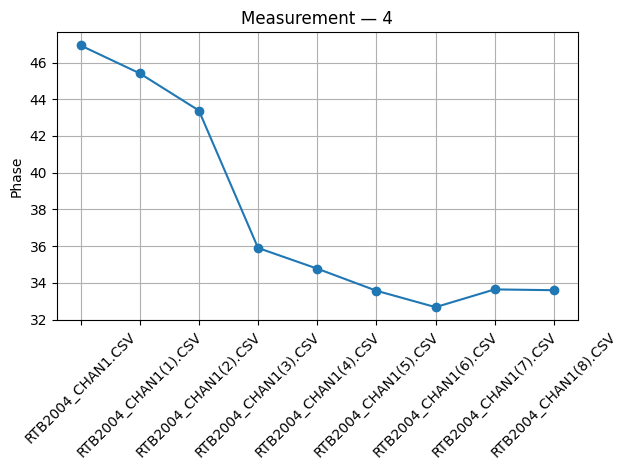


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\5
RTB2004_CHAN1.CSV → phase = 50.2498791478371
RTB2004_CHAN1(1).CSV → phase = 48.15447365905061
RTB2004_CHAN1(2).CSV → phase = 46.628894623250865
RTB2004_CHAN1(3).CSV → phase = 42.334966559191336
RTB2004_CHAN1(4).CSV → phase = 41.979105266284876
RTB2004_CHAN1(5).CSV → phase = 40.14650737364101
RTB2004_CHAN1(6).CSV → phase = 39.58184226659235
RTB2004_CHAN1(7).CSV → phase = 37.72406437692986
RTB2004_CHAN1(8).CSV → phase = 36.71292780818348
RTB2004_CHAN1(9).CSV → phase = 34.207526107535266


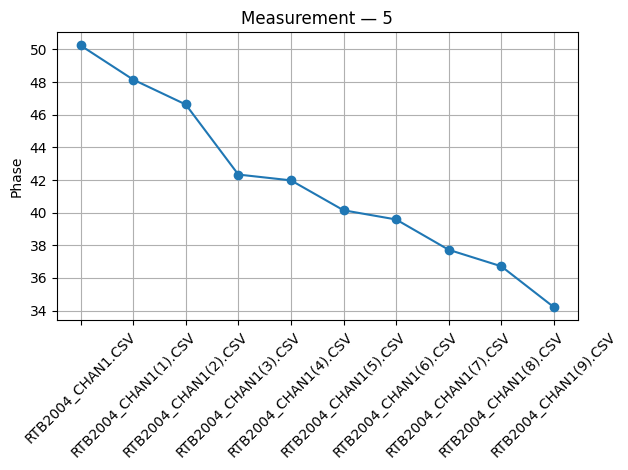

In [14]:
import glob
import re

def extract_index(filename):
    """
    CHAN1.csv -> 0
    CHAN1(1).csv -> 1
    CHAN1(2).csv -> 2
    """
    match = re.search(r"\((\d+)\)", filename)
    if match:
        return int(match.group(1))
    return 0  # базовый файл — первый


def sort_files(file_list):
    return sorted(file_list, key=lambda x: extract_index(os.path.basename(x)))

# --- корневая папка ---
root_dir = os.path.join(os.getcwd(), "data", "bio")

# --- обходим ВСЕ подпапки ---
for subdir, dirs, files in os.walk(root_dir):

    chan1_files = glob.glob(os.path.join(subdir, "RTB2004_CHAN1*.csv"))
    chan2_files = glob.glob(os.path.join(subdir, "RTB2004_CHAN2*.csv"))

    if not chan1_files or not chan2_files:
        continue  # пропускаем пустые папки

    # правильная сортировка
    chan1_files = sort_files(chan1_files)
    chan2_files = sort_files(chan2_files)

    phases = []
    labels = []

    print(f"\n📁 Обработка папки: {subdir}")

    for f1, f2 in zip(chan1_files, chan2_files):

        t, U = md.make_real_data_list(f1)
        t, I = md.make_real_data_list(f2)

        F, V = md.get_spectrum3(t, U)
        F_peak_calc = F[np.argmax(V)]

        t_f, U_f = md.filter_butter_bandpass(t, U, F_peak_calc, 200e3, 2)
        t_f, I_f = md.filter_butter_bandpass(t, I, F_peak_calc, 200e3, 2)

        phase = md.get_phase_FFT(t_f, I_f, U_f, F_peak_calc)

        phases.append(phase)
        labels.append(os.path.basename(f1))

        print(f"{os.path.basename(f1)} → phase = {phase}")

    # --- график для каждой папки ---
    plt.figure()
    plt.plot(phases, marker='o')

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.ylabel("Phase")
    plt.title(f"Measurement — {os.path.basename(subdir)}")
    plt.grid()
    plt.tight_layout()

    plt.show()